In [24]:
import sys
from pathlib import Path

def find_repo_root_local(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "tools").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root.")

REPO_ROOT = find_repo_root_local(Path.cwd())
SRC_DIR = REPO_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import glob
import importlib
import json
import math
import random

import hypernetx as hnx
import matplotlib.pyplot as plt
import numpy as np
import ot
import pandas
import pd
import plotly.express as px
import plotly.graph_objects as go
import scipy as sp
import seaborn as sb
import sklearn as sk
import sklearn.decomposition
import topo_util
import tpot
from entropy import hyper_edge_entropy, hyper_graph_entropy, hypergraph_shannon_entropy, persist_entropy
from experiment_utils import align_2d as align
from experiment_utils import compute_coot_ot_gw_distances, convex_point, geodesic_distances, get_affinities, reflect_points as reflect, zscore
from experiment_utils import geodesic_distances_coot, geodesic_distances_gw, geodesic_distances_iota
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot, plot
from plotly.subplots import make_subplots
from synthetic_data import generate_bistable_dataset, generate_full_dataset, sample_1to2, sample_rvp_reproducible
from topo_util import noisy_circle, noisy_ellipses
from tqdm import tqdm

init_notebook_mode(connected=True)

import topfmain


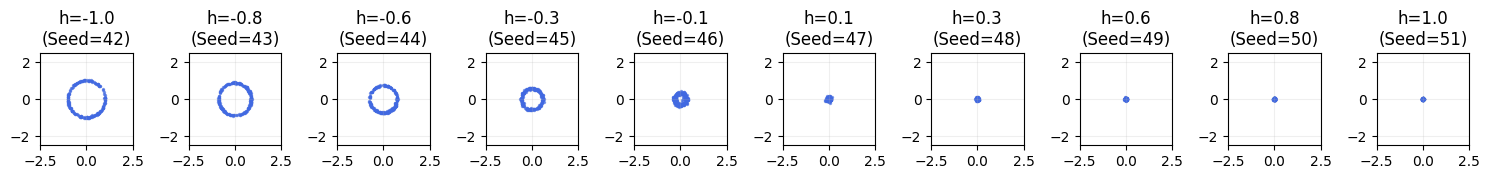

数据集形状: (10200, 3)


In [25]:
MAIN_SEED = 42
h_values = np.linspace(-1, 1, 10)

plt.figure(figsize=(15, 3.5))
for idx, h_val in enumerate(h_values):
    current_seed = MAIN_SEED + idx
    points = sample_rvp_reproducible(h_val, n_samples=200, T=0.001, seed=current_seed)
    ax = plt.subplot(1, 10, idx + 1)
    ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.6, c='royalblue')
    ax.set_title(f'h={h_val:.1f}\n(Seed={current_seed})')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

dataset = generate_full_dataset(seed=42)
print(f"Dataset shape: {dataset.shape}")


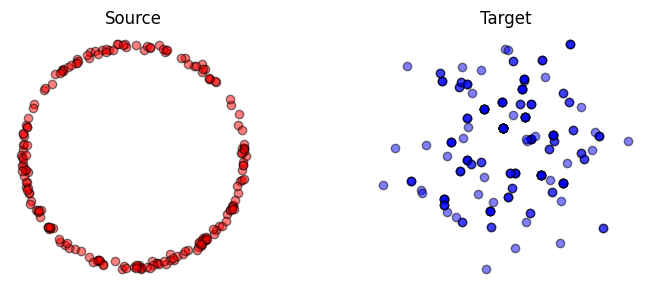

In [26]:
mask = dataset[:,0] == -1
A = dataset[mask][:,1:]
mask = dataset[:,0] == 1
B = dataset[mask][:,1:]

plt.figure(figsize = (8, 3))
plt.subplot(1, 2, 1)
plt.scatter(A[:,0],A[:,1], color = 'red', edgecolors = 'k', alpha = 0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.axis("off")
plt.title("Source")
plt.subplot(1, 2, 2)
plt.scatter(B[:,0],B[:,1], color = 'blue', edgecolors = 'k', alpha = 0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.axis("off")
plt.title("Target")
plt.tight_layout()
plt.show()


In [27]:
C_v0, C_v1 = get_affinities(A), get_affinities(B)
p, q = ot.unif(len(A)), ot.unif(len(B))

topf_all = [topfmain.topf(x, return_dict = True, complex_type = 'rips', fixed_num_features = [0,4]) for x in tqdm([A, B])]
y0 = topf_all[0][0]
y1 = topf_all[1][0]
df1, df2 = [pandas.DataFrame({"b" : x[1]['birth_times'], "d" : x[1]['death_times'], "pers" : np.array(x[1]['death_times']) - np.array(x[1]['birth_times'])}) for x in topf_all]
p_spt, q_spt = df1.iloc[:, :2].values, df2.iloc[:, :2].values

p, q = pd.augmented_weights(p_spt, q_spt)
C = pd.augmented_cost(p_spt, q_spt)
C_pd = pd.augmented_cost(p_spt, q_spt); C_pd /= C_pd.mean()

C_v0, C_v1 = get_affinities(A), get_affinities(B)

alpha = 0.5
beta = 1

w0 = ot.unif(y0.shape[0])
w1 = ot.unif(y1.shape[0])
v0 = p
v1 = q
pi_s, pi_f, _, = tpot.TPOT(y0, y1, w0, w1, v0, v1,
                           C_v0, C_v1, C_pd,
                           beta = beta, alpha = alpha, print_iter = 50, iter = 100,
                           solver = "sinkhorn",
                           eps_s = 0.003, eps_f = 0.01, numItermax = 2500)

P = (pi_s / pi_s.sum(axis=-1)[:, np.newaxis])
Q = (pi_f[:-1, :-1] / pi_f[:-1, :-1].sum(axis=-1)[:, np.newaxis])
Q[np.isnan(Q)] = 0


100%|██████████| 2/2 [00:20<00:00, 10.07s/it]


Iteration 0,	 obj = 0.2615112248358502,	 obj_terms = {'coot': 0.08271406377794227, 'ot': 0.13804889985305327, 'gw': 0.04074826120485465}
Iteration 50,	 obj = 0.2328474002728187,	 obj_terms = {'coot': 0.0802835563633116, 'ot': 0.13808365878085033, 'gw': 0.014480185128656793}


In [28]:
matching = np.array(np.where(ot.emd(w0, w1, pi_s.max()-pi_s) > 0)).T

point_matching = []
pi_s_T = pi_s.T
for i in range(len(pi_s_T[:][-1])):
    sorted_indices = np.argsort(pi_s_T[i])
    point_matching.append([i, sorted_indices[-1]])

cycle_matching = []
pi_f_T = pi_f.T
for i in range(len(pi_f_T[:][-1])):
    sorted_indices = np.argsort(pi_f_T[i])
    cycle_matching.append([i, sorted_indices[-1]])



In [29]:
num_frames = 51
x1 = np.linspace(0, 1, num_frames, endpoint=True)
matrices = [geodesic_distances(A, B, t, matching) for t in x1]
convex_points = np.array([convex_point(A, B, t, matching) for t in x1])

from matplotlib.collections import LineCollection
from sklearn import manifold
from sklearn.manifold import MDS
from sklearn.metrics import euclidean_distances, pairwise_distances

model = MDS(n_components=2, dissimilarity='precomputed', random_state=2002)

import warnings
warnings.filterwarnings("ignore")
models = []
out = model.fit(matrices[0]).embedding_
pos = align(out, convex_points[0])
models_alligned = [pos]
for ii in range(1, num_frames):
    true = convex_points[ii]
    out = model.fit(matrices[ii]).embedding_
    pos = align(out, true)
    rpos = reflect(pos)
    if np.linalg.norm(models_alligned[-1] - pos) > np.linalg.norm(models_alligned[-1] - rpos):
        pos = rpos
    models.append(out)
    models_alligned.append(pos)


In [31]:
coot_values = []
ot_values = []
gw_values = []
total_values = []
coot_values_1 = []
ot_values_1 = []
gw_values_1 = []
total_values_1 = []
pe_values = []#persistent entropy
hge_values = []#hyper graph entropy(new defined)
hse_values = []#hypergraph shannon entropy
hee_values = []#hyperedge entropy
geodesic_pd = []#PD on the geodesic
sym_values = []#symmetric hypergraph entropy
pe_values_1 = []#persistent entropy
hge_values_1 = []#hyper graph entropy(new defined)
hse_values_1 = []#hypergraph shannon entropy
hee_values_1 = []#hyperedge entropy
geodesic_pd_1 = []#PD on the geodesic
sym_values_1 = []#symmetric hypergraph entropy
num_points = len(A)

para_alpha = 0.5
for i in range(1,num_frames):
    t = i/num_frames
    y1_t = geodesic_distances_coot(y1,y0,t,point_matching,cycle_matching)
    C2_t = geodesic_distances_gw(B,A,t, point_matching)
    geodesic_pd_point = geodesic_distances_iota(q_spt, p_spt, t, cycle_matching)

    pe_value = persist_entropy(geodesic_pd_point)
    hge_value = hyper_graph_entropy(y1_t)
    hee_value = hyper_edge_entropy(y1_t)
    hse_value = hypergraph_shannon_entropy(y1_t)

    p, q = pd.augmented_weights(p_spt, geodesic_pd_point)
    C = pd.augmented_cost(p_spt, geodesic_pd_point)
    C_pd_t = pd.augmented_cost(p_spt, geodesic_pd_point); C_pd_t /= C_pd_t.mean()
    C_v1_t = C2_t
    C_v1_t /= np.mean(C2_t)
    C_v1_t = np.exp(-C_v1_t)
    value = compute_coot_ot_gw_distances(y0, y1_t,
                           C_v0, C_v1_t, C_pd_t,
                           pi_s, pi_f,
                           alpha = alpha, beta=beta)
    coot_values_1.append(value[0]/beta)
    ot_values_1.append(value[1]/(1-alpha))
    gw_values_1.append(value[2]/alpha)
    total_values_1.append(value[0]+value[1]+value[2])

    pe_values_1.append(pe_value)
    hge_values_1.append(hge_value)
    hee_values_1.append(hee_value)
    hse_values_1.append(hse_value)
    sym_values_1.append(para_alpha * hge_value + (1-para_alpha) * hee_value)
    print(f'Time Stamp:{i}')

for i in range(1, num_frames):
    G = models_alligned[i-1]
    C_vt = get_affinities(G)
    g = ot.unif(len(G))
    topf_all = [topfmain.topf(x, return_dict = True, complex_type = 'rips', fixed_num_features = [0,4]) for x in tqdm([G])]
    yt = topf_all[0][0]
    dft = [pandas.DataFrame({"b" : x[1]['birth_times'], "d" : x[1]['death_times'], "pers" : np.array(x[1]['death_times']) - np.array(x[1]['birth_times'])}) for x in topf_all]
    g_spt = dft[0].iloc[:, :2].values
    p, g = pd.augmented_weights(p_spt, g_spt)
    C = pd.augmented_cost(p_spt, g_spt)
    C_pd = pd.augmented_cost(p_spt, g_spt); C_pd /= C_pd.mean()

    alpha = 0.5
    beta = 1

    w0 = ot.unif(y0.shape[0])
    wt = ot.unif(yt.shape[0])
    v0 = p
    vt = g
    pi_s, pi_f, _, = tpot.TPOT(y0, yt, w0, wt, v0, vt,
                            C_v0, C_vt, C_pd,
                            beta = beta, alpha = alpha, print_iter = 50, iter = 100,
                            solver = "sinkhorn",
                            eps_s = 0.003, eps_f = 0.01, numItermax = 2500)

    P = (pi_s / pi_s.sum(axis=-1)[:, np.newaxis])
    Q = (pi_f[:-1, :-1] / pi_f[:-1, :-1].sum(axis=-1)[:, np.newaxis])
    Q[np.isnan(Q)] = 0

    value = compute_coot_ot_gw_distances(y0, yt,
                           C_v0, C_vt, C_pd,
                           pi_s, pi_f,
                           alpha = alpha, beta=beta)
    coot_values.append(value[0]/beta)
    ot_values.append(value[1]/(1-alpha))
    gw_values.append(value[2]/alpha)
    total_values.append(value[2] + value[1] + value[0])

    pe_value = persist_entropy(g_spt)
    hge_value = hyper_graph_entropy(yt)
    hee_value = hyper_edge_entropy(yt)
    hse_value = hypergraph_shannon_entropy(yt)

    if i%20 == 0:
        geodesic_pd.append(g_spt)

    pe_values.append(pe_value)
    hge_values.append(hge_value)
    hee_values.append(hee_value)
    hse_values.append(hse_value)
    sym_values.append(para_alpha * hge_value + (1-para_alpha) * hee_value)

    print(f'Time Stamp:{i}')


Time Stamp:1
Time Stamp:2
Time Stamp:3
Time Stamp:4
Time Stamp:5
Time Stamp:6
Time Stamp:7
Time Stamp:8
Time Stamp:9
Time Stamp:10
Time Stamp:11
Time Stamp:12
Time Stamp:13
Time Stamp:14
Time Stamp:15
Time Stamp:16
Time Stamp:17
Time Stamp:18
Time Stamp:19
Time Stamp:20
Time Stamp:21
Time Stamp:22
Time Stamp:23
Time Stamp:24
Time Stamp:25
Time Stamp:26
Time Stamp:27
Time Stamp:28
Time Stamp:29
Time Stamp:30
Time Stamp:31
Time Stamp:32
Time Stamp:33
Time Stamp:34
Time Stamp:35
Time Stamp:36
Time Stamp:37
Time Stamp:38
Time Stamp:39
Time Stamp:40
Time Stamp:41
Time Stamp:42
Time Stamp:43
Time Stamp:44
Time Stamp:45
Time Stamp:46
Time Stamp:47
Time Stamp:48
Time Stamp:49
Time Stamp:50


100%|██████████| 1/1 [00:08<00:00,  8.26s/it]


Iteration 0,	 obj = 0.055515436559948325,	 obj_terms = {'coot': 0.009911259164200995, 'ot': 7.433627179809094e-05, 'gw': 0.04552984112394924}
is_converged, obj = 0.0069228158353607525, obj_new = 0.006922815916443846
Time Stamp:1


100%|██████████| 1/1 [00:08<00:00,  8.42s/it]


Iteration 0,	 obj = 0.05561102387116659,	 obj_terms = {'coot': 0.009911172737119736, 'ot': 0.0001710168978331236, 'gw': 0.04552883423621373}
is_converged, obj = 0.007019555670922666, obj_new = 0.007019555751017953
Time Stamp:2


...

Iteration 0,	 obj = 0.2831908107075627,	 obj_terms = {'coot': 0.09496958005272728, 'ot': 0.14372028050686242, 'gw': 0.04450095014797302}
Iteration 50,	 obj = 0.24224087734189445,	 obj_terms = {'coot': 0.09282335667986788, 'ot': 0.14361768767710933, 'gw': 0.005799832984917228}
Time Stamp:48


100%|██████████| 1/1 [00:08<00:00,  8.69s/it]


Iteration 0,	 obj = 0.2848545033301464,	 obj_terms = {'coot': 0.09961127753172498, 'ot': 0.1413661648339664, 'gw': 0.043877060964454984}
Iteration 50,	 obj = 0.24447035939036257,	 obj_terms = {'coot': 0.09678364966178465, 'ot': 0.14143303563860188, 'gw': 0.006253674089976045}
is_converged, obj = 0.24447064202603114, obj_new = 0.24447064114147896
Time Stamp:49


100%|██████████| 1/1 [00:08<00:00,  8.57s/it]


Iteration 0,	 obj = 0.2640043193897071,	 obj_terms = {'coot': 0.08188013872830474, 'ot': 0.13955947724581685, 'gw': 0.04256470341558549}
Iteration 50,	 obj = 0.22578753618480507,	 obj_terms = {'coot': 0.07879695263462021, 'ot': 0.13960763259489065, 'gw': 0.0073829509552942405}
is_converged, obj = 0.2257875247931192, obj_new = 0.22578752575558395
Time Stamp:50


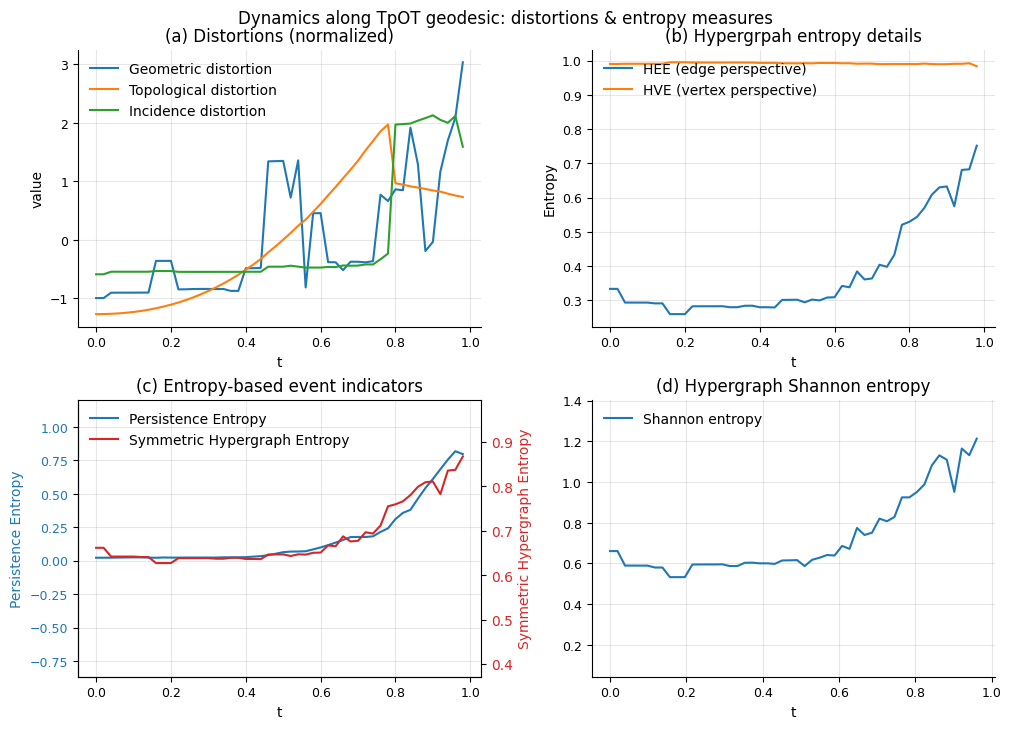

In [32]:
hse_rate = [hse_values[i] - hse_values[i-1] for i in range(1,len(hse_values))]
hge_rate = [hge_values[i] - hge_values[i-1] for i in range(1,len(hge_values))]

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(ot_values))

geom = np.asarray(gw_values)        # 几何（你原来的 gw_values / geom Values）
topo = np.asarray(ot_values)         # 拓扑
hyper = np.asarray(coot_values)      # 超图/Incidence（你原来 coot 或类似）

PE = np.asarray(pe_values)           # Persistence entropy
HE = np.asarray(hge_values)          # Hypergraph entropy
HEE = np.asarray(hee_values)         # Hyperedge-perspective entropy（或用 HEV）
SHE = np.asarray(sym_values)         # Symmetric hypergraph entropy
HSE = np.asarray(hse_values)

HSE_rate = np.asarray(hse_rate)

geom_z, topo_z, hyper_z = map(zscore, [geom, topo, hyper])
PE_z, HE_z, HEE_z, SHE_z = map(zscore, [PE, HE, HEE, SHE])

fig = plt.figure(figsize=(10, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2)

axA = fig.add_subplot(gs[0, 0])  # (a)
axB = fig.add_subplot(gs[1, 0])  # (c)
axC = fig.add_subplot(gs[0, 1])  # (b)
axD = fig.add_subplot(gs[1, 1])  # (d)

axA.plot(x/(num_frames-1), geom_z, label='Geometric distortion')
axA.plot(x/(num_frames-1), topo_z, label='Topological distortion')
axA.plot(x/(num_frames-1), hyper_z, label='Incidence distortion')
axA.set_title('(a) Distortions (normalized)')
axA.set_xlabel('t')
axA.set_ylabel('value')
axA.grid(True, alpha=0.3)
axA.legend(loc='upper left', ncol=1, frameon=False)

color_left = 'tab:blue'
color_right = 'tab:red'

axB.plot(x / (num_frames - 1), PE, color=color_left, label='Persistence Entropy')
axB.set_xlabel('t')
axB.set_ylabel('Persistence Entropy', color=color_left)
axB.tick_params(axis='y', labelcolor=color_left)
axB.grid(True, alpha=0.3)

axB_r = axB.twinx()
axB_r.plot(x / (num_frames - 1), SHE, color=color_right, label='Symmetric Hypergraph Entropy')
axB_r.set_ylabel('Symmetric Hypergraph Entropy', color=color_right)
axB_r.tick_params(axis='y', labelcolor=color_right)

she_mean = np.nanmean(SHE)
she_range = np.nanmax(SHE) - np.nanmin(SHE)
pe_mean = np.nanmean(PE)
pe_range = np.nanmax(PE) - np.nanmin(PE)
axB.set_ylim(pe_mean - 1.3 * pe_range, pe_mean + 1.3 * pe_range)
axB_r.set_ylim(she_mean - 1.3 * she_range, she_mean + 1.3 * she_range)

axB.set_title('(c) Entropy-based event indicators')
lines, labels = axB.get_legend_handles_labels()
lines2, labels2 = axB_r.get_legend_handles_labels()
axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

lines, labels = axB.get_legend_handles_labels()
lines2, labels2 = axB_r.get_legend_handles_labels()
axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

axC.plot(x/(num_frames-1), HEE, label='HEE (edge perspective)')
axC.plot(x/(num_frames-1), HE, label='HVE (vertex perspective)')
axC.set_title('(b) Hypergrpah entropy details')
axC.set_xlabel('t')
axC.set_ylabel('Entropy')
axC.grid(True, alpha=0.3)
axC.legend(loc='upper left', ncol=1, frameon=False)

axD.plot(x[:]/(num_frames), HSE, label='Shannon entropy')
HSE_mean = np.nanmean(HSE)
HSE_range = np.nanmax(HSE)- np.nanmin(HSE)
axD.set_ylim(HSE_mean - 1*HSE_range, HSE_mean + 1*HSE_range)

axD.set_title('(d) Hypergraph Shannon entropy')
axD.set_xlabel('t')
axD.grid(True, alpha=0.3)
axD.legend(loc='upper left', ncol=1, frameon=False)

for ax in [axA, axB, axC, axD]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=9)

fig.suptitle('Dynamics along TpOT geodesic: distortions & entropy measures', y=1.02)
plt.show()


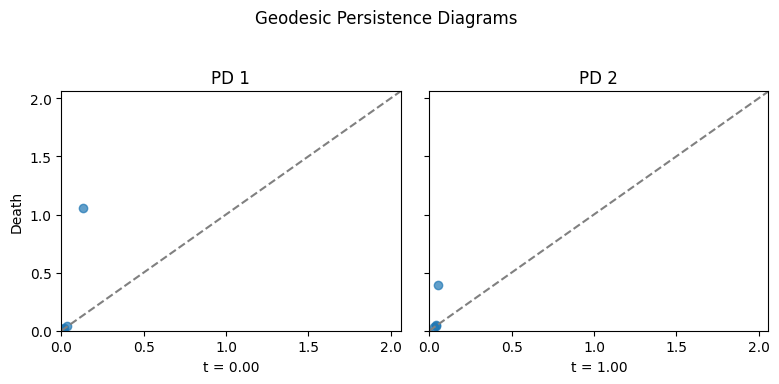

In [33]:
import matplotlib.pyplot as plt

def plot_geodesic_pds(geodesic_pd):
    """
    在一行里并排绘制所有 geodesic_pd 中的持久性图（[birth, death] 对）
    x 轴用 t 从 0 到 1 均匀分布标注
    """
    n = len(geodesic_pd)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
    max_value = np.max(geodesic_pd)
    for i, pd in enumerate(geodesic_pd):
        ax = axes[i]
        births = pd[:, 0]
        deaths = pd[:, 1]
        ax.scatter(births, deaths, alpha=0.7)
        ax.plot([0, max_value+1], [0, max_value+1], linestyle='--', color='gray')
        ax.set_xlim(0, max_value+1)
        ax.set_ylim(0, max_value+1)
        t_val = i / (n - 1) if n > 1 else 0
        ax.set_xlabel(f"t = {t_val:.2f}")
        if i == 0:
            ax.set_ylabel("Death")
        ax.set_title(f"PD {i+1}")

    fig.suptitle("Geodesic Persistence Diagrams")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_geodesic_pds(geodesic_pd)


In [34]:
import pd
coot_values_gt = []
ot_values_gt = []
gw_values_gt = []
total_values_gt = []
pe_values_gt = []#persistent entropy
hge_values_gt = []#hyper graph entropy(new defined)
hse_values_gt = []#hypergraph shannon entropy
hee_values_gt = []#hyperedge entropy
geodesic_pd_gt = []#PD on the geodesic
sym_values_gt = []#symmetric hypergraph entropy
h_index = np.unique(dataset[:,0])
for h in h_index:
    mask = dataset[:,0] == h
    print(f'h={h}')
    X_t = dataset[mask][:,1:]
    C_vt = get_affinities(X_t)
    topf_all = [topfmain.topf(x, return_dict = True, complex_type = 'rips', fixed_num_features = [0,4]) for x in tqdm([X_t])]
    yt = topf_all[0][0]
    dft = [pandas.DataFrame({"b" : x[1]['birth_times'], "d" : x[1]['death_times'], "pers" : np.array(x[1]['death_times']) - np.array(x[1]['birth_times'])}) for x in topf_all]
    g_spt = dft[0].iloc[:, :2].values

    p, g = pd.augmented_weights(p_spt, g_spt)
    C = pd.augmented_cost(p_spt, g_spt)
    C_pd = pd.augmented_cost(p_spt, g_spt); C_pd /= C_pd.mean()

    alpha = 0.5
    beta = 1

    w0 = ot.unif(y0.shape[0])
    wt = ot.unif(yt.shape[0])
    v0 = p
    vt = g
    pi_s, pi_f, _, = tpot.TPOT(y0, yt, w0, wt, v0, vt,
                            C_v0, C_vt, C_pd,
                            beta = beta, alpha = alpha, print_iter = 50, iter = 100,
                            solver = "sinkhorn",
                            eps_s = 0.003, eps_f = 0.01, numItermax = 2500)

    P = (pi_s / pi_s.sum(axis=-1)[:, np.newaxis])
    Q = (pi_f[:-1, :-1] / pi_f[:-1, :-1].sum(axis=-1)[:, np.newaxis])
    Q[np.isnan(Q)] = 0

    value = compute_coot_ot_gw_distances(y0, yt,
                           C_v0, C_vt, C_pd,
                           pi_s, pi_f,
                           alpha = alpha, beta=beta)
    coot_values_gt.append(value[0]/beta)
    ot_values_gt.append(value[1]/(1-alpha))
    gw_values_gt.append(value[2]/alpha)
    total_values_gt.append(value[2] + value[1] + value[0])

    pe_value = persist_entropy(g_spt)
    hge_value = hyper_graph_entropy(yt)
    hee_value = hyper_edge_entropy(yt)
    hse_value = hypergraph_shannon_entropy(yt)

    geodesic_pd_gt.append(g_spt)

    pe_values_gt.append(pe_value)
    hge_values_gt.append(hge_value)
    hee_values_gt.append(hee_value)
    hse_values_gt.append(hse_value)
    sym_values_gt.append(para_alpha * hge_value + (1-para_alpha) * hee_value)


h=-1.0


100%|██████████| 1/1 [00:08<00:00,  8.62s/it]


Iteration 0,	 obj = 0.05551204305656467,	 obj_terms = {'coot': 0.009912324955535111, 'ot': 7.377859952883944e-05, 'gw': 0.04552593950150072}
is_converged, obj = 0.006909435949810561, obj_new = 0.006909436016267788
h=-0.96


100%|██████████| 1/1 [00:08<00:00,  8.53s/it]


Iteration 0,	 obj = 0.05417358534423519,	 obj_terms = {'coot': 0.010500987054642561, 'ot': 0.0003594685229074496, 'gw': 0.04331312976668518}
Iteration 50,	 obj = 0.014263441869728612,	 obj_terms = {'coot': 0.007475557938867889, 'ot': 0.00039487978386244625, 'gw': 0.006393004146998277}
is_converged, obj = 0.014263436091933555, obj_new = 0.01426343690615119
h=-0.92


...

Iteration 0,	 obj = 0.2498145723758568,	 obj_terms = {'coot': 0.07057216255941892, 'ot': 0.13863819760827653, 'gw': 0.04060421220816135}
Iteration 50,	 obj = 0.22129089344611053,	 obj_terms = {'coot': 0.06762592955904663, 'ot': 0.13868179110174117, 'gw': 0.014983172785322754}
is_converged, obj = 0.2212908686377978, obj_new = 0.22129086781239463
h=0.96


100%|██████████| 1/1 [00:08<00:00,  8.67s/it]


Iteration 0,	 obj = 0.24981461007282513,	 obj_terms = {'coot': 0.07057214953520162, 'ot': 0.13863824648462988, 'gw': 0.04060421405299362}
Iteration 50,	 obj = 0.2212909554044284,	 obj_terms = {'coot': 0.0676259404399237, 'ot': 0.13868183976965567, 'gw': 0.014983175194849001}
is_converged, obj = 0.2212909305862288, obj_new = 0.2212909297565932
h=1.0


100%|██████████| 1/1 [00:08<00:00,  8.68s/it]


Iteration 0,	 obj = 0.26151114543175175,	 obj_terms = {'coot': 0.08271400236988016, 'ot': 0.13804887798855553, 'gw': 0.04074826507331605}
Iteration 50,	 obj = 0.23284731829134692,	 obj_terms = {'coot': 0.08028350797445892, 'ot': 0.1380836392674894, 'gw': 0.014480171049398614}


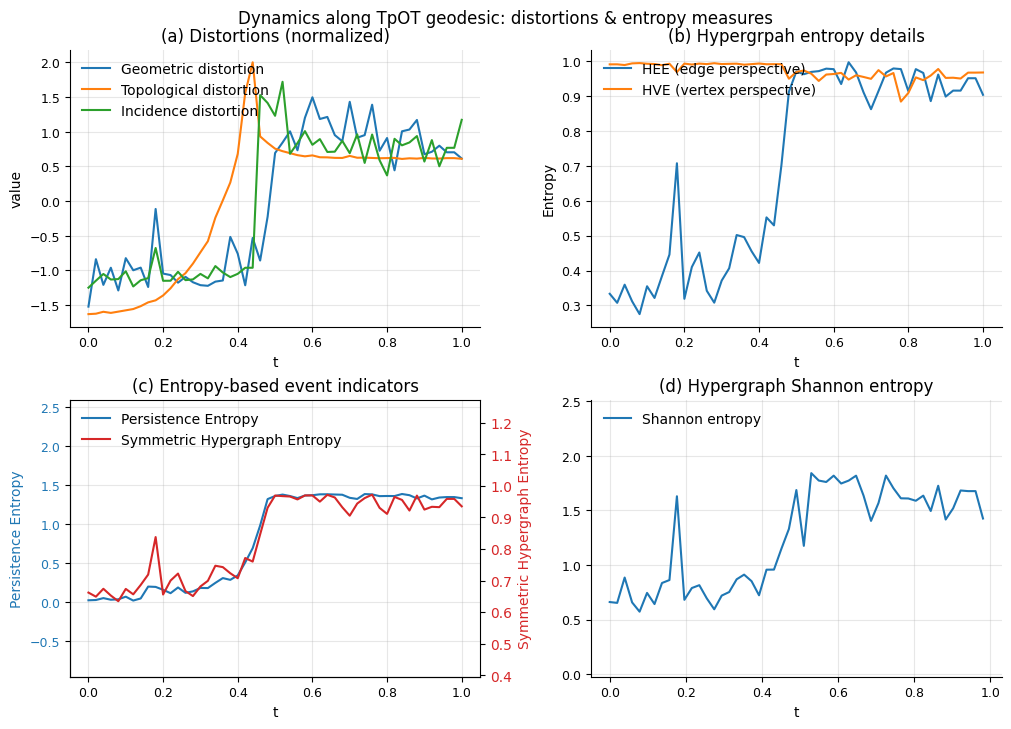

In [35]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(pe_values_gt))

geom = np.asarray(gw_values_gt)        # 几何（你原来的 gw_values / geom Values）
topo = np.asarray(ot_values_gt)         # 拓扑
hyper = np.asarray(coot_values_gt)      # 超图/Incidence（你原来 coot 或类似）

PE = np.asarray(pe_values_gt)           # Persistence entropy
HE = np.asarray(hge_values_gt)          # Hypergraph entropy
HEE = np.asarray(hee_values_gt)         # Hyperedge-perspective entropy（或用 HEV）
SHE = np.asarray(sym_values_gt)         # Symmetric hypergraph entropy
HSE = np.asarray(hse_values_gt)

PE_z, HE_z, HEE_z, SHE_z = map(zscore, [PE, HE, HEE, SHE])
geom_z, topo_z, hyper_z = map(zscore, [geom, topo, hyper])

fig = plt.figure(figsize=(10, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2)

axA = fig.add_subplot(gs[0, 0])  # (a)
axB = fig.add_subplot(gs[1, 0])  # (c)
axC = fig.add_subplot(gs[0, 1])  # (b)
axD = fig.add_subplot(gs[1, 1])  # (d)

axA.plot(x/(num_frames-1), geom_z, label='Geometric distortion')
axA.plot(x/(num_frames-1), topo_z, label='Topological distortion')
axA.plot(x/(num_frames-1), hyper_z, label='Incidence distortion')
axA.set_title('(a) Distortions (normalized)')
axA.set_xlabel('t')
axA.set_ylabel('value')
axA.grid(True, alpha=0.3)
axA.legend(loc='upper left', ncol=1, frameon=False)

color_left = 'tab:blue'
color_right = 'tab:red'

axB.plot(x / (num_frames - 1), PE, color=color_left, label='Persistence Entropy')
axB.set_xlabel('t')
axB.set_ylabel('Persistence Entropy', color=color_left)
axB.tick_params(axis='y', labelcolor=color_left)
axB.grid(True, alpha=0.3)

axB_r = axB.twinx()
axB_r.plot(x / (num_frames - 1), SHE, color=color_right, label='Symmetric Hypergraph Entropy')
axB_r.set_ylabel('Symmetric Hypergraph Entropy', color=color_right)
axB_r.tick_params(axis='y', labelcolor=color_right)

she_mean = np.nanmean(SHE)
she_range = np.nanmax(SHE) - np.nanmin(SHE)
pe_mean = np.nanmean(PE)
pe_range = np.nanmax(PE) - np.nanmin(PE)
axB.set_ylim(pe_mean - 1.3 * pe_range, pe_mean + 1.3 * pe_range)
axB_r.set_ylim(she_mean - 1.3 * she_range, she_mean + 1.3 * she_range)

axB.set_title('(c) Entropy-based event indicators')
lines, labels = axB.get_legend_handles_labels()
lines2, labels2 = axB_r.get_legend_handles_labels()
axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

lines, labels = axB.get_legend_handles_labels()
lines2, labels2 = axB_r.get_legend_handles_labels()
axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

axC.plot(x/(num_frames-1), HEE, label='HEE (edge perspective)')
axC.plot(x/(num_frames-1), HE, label='HVE (vertex perspective)')
axC.set_title('(b) Hypergrpah entropy details')
axC.set_xlabel('t')
axC.set_ylabel('Entropy')
axC.grid(True, alpha=0.3)
axC.legend(loc='upper left', ncol=1, frameon=False)

axD.plot(x[:]/(num_frames), HSE, label='Shannon entropy')
HSE_mean = np.nanmean(HSE)
HSE_range = np.nanmax(HSE)- np.nanmin(HSE)
axD.set_ylim(HSE_mean - 1*HSE_range, HSE_mean + 1*HSE_range)

axD.set_title('(d) Hypergraph Shannon entropy')
axD.set_xlabel('t')
axD.grid(True, alpha=0.3)
axD.legend(loc='upper left', ncol=1, frameon=False)

for ax in [axA, axB, axC, axD]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=9)

fig.suptitle('Dynamics along TpOT geodesic: distortions & entropy measures', y=1.02)
plt.show()


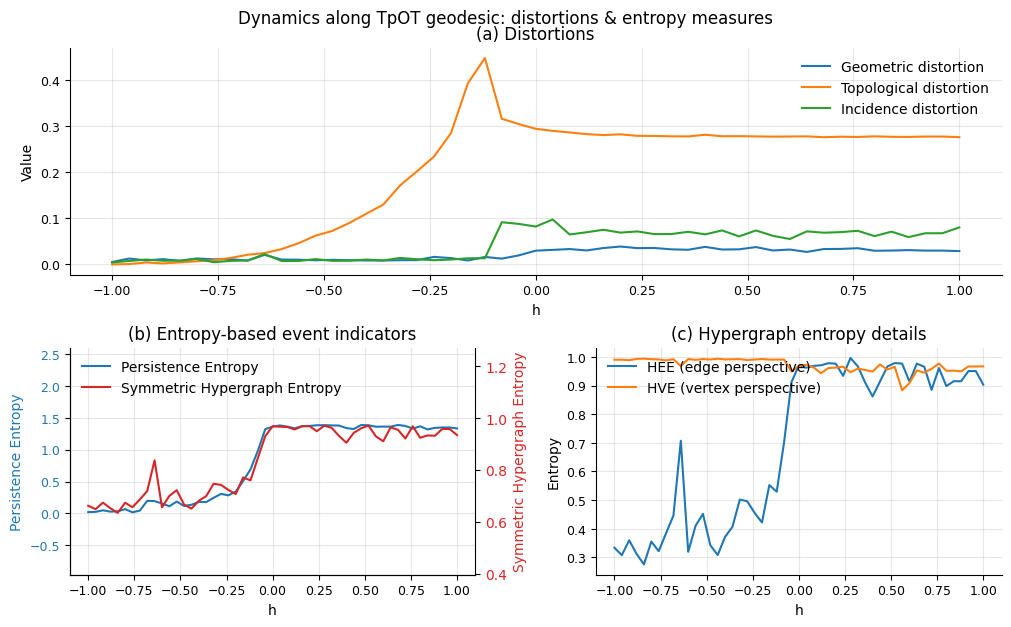

In [39]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6), constrained_layout=True)

gs = fig.add_gridspec(2, 2)

axA = fig.add_subplot(gs[0, :])

axB = fig.add_subplot(gs[1, 0])

axC = fig.add_subplot(gs[1, 1])

axA.plot(h_index, geom, label='Geometric distortion')
axA.plot(h_index, topo, label='Topological distortion')
axA.plot(h_index, hyper, label='Incidence distortion')
axA.set_title('(a) Distortions')
axA.set_xlabel('h')
axA.set_ylabel('Value')
axA.grid(True, alpha=0.3)
axA.legend(loc='upper right', ncol=1, frameon=False) # 图变宽了，Legend 放右上可能更好

color_left = 'tab:blue'
color_right = 'tab:red'

axB.plot(h_index, PE, color=color_left, label='Persistence Entropy')
axB.set_xlabel('h')
axB.set_ylabel('Persistence Entropy', color=color_left)
axB.tick_params(axis='y', labelcolor=color_left)
axB.grid(True, alpha=0.3)

axB_r = axB.twinx()
axB_r.plot(h_index, SHE, color=color_right, label='Symmetric Hypergraph Entropy')
axB_r.set_ylabel('Symmetric Hypergraph Entropy', color=color_right)
axB_r.tick_params(axis='y', labelcolor=color_right)

she_mean = np.nanmean(SHE)
she_range = np.nanmax(SHE) - np.nanmin(SHE)
pe_mean = np.nanmean(PE)
pe_range = np.nanmax(PE) - np.nanmin(PE)

if pe_range == 0: pe_range = 1.0
if she_range == 0: she_range = 1.0

axB.set_ylim(pe_mean - 1.3 * pe_range, pe_mean + 1.3 * pe_range)
axB_r.set_ylim(she_mean - 1.3 * she_range, she_mean + 1.3 * she_range)

axB.set_title('(b) Entropy-based event indicators') # 序号顺延改为 (b)

lines, labels = axB.get_legend_handles_labels()
lines2, labels2 = axB_r.get_legend_handles_labels()
axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

axC.plot(h_index, HEE, label='HEE (edge perspective)')
axC.plot(h_index, HE, label='HVE (vertex perspective)')

axC.set_title('(c) Hypergraph entropy details') # 序号顺延改为 (c)
axC.set_xlabel('h')
axC.set_ylabel('Entropy')
axC.grid(True, alpha=0.3)
axC.legend(loc='upper left', ncol=1, frameon=False)

for ax in [axA, axB, axC]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax == axB:
        axB_r.spines['top'].set_visible(False)

    ax.tick_params(axis='both', which='major', labelsize=9)

fig.suptitle('Dynamics along TpOT geodesic: distortions & entropy measures', y=1.02)

plt.show()


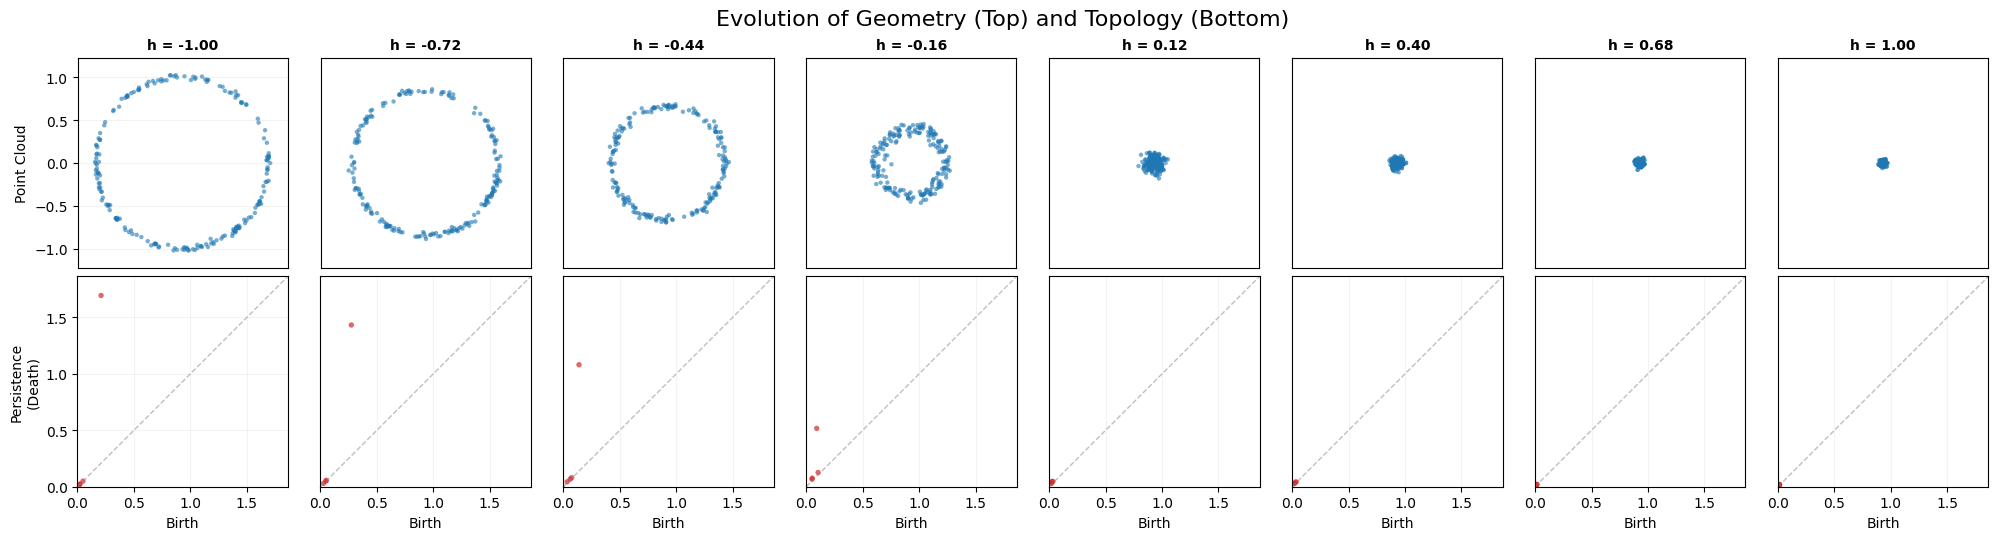

In [37]:
import numpy as np
import matplotlib.pyplot as plt

h_index = np.unique(dataset[:,0])
point_clouds = []
for h in h_index:
    mask = dataset[:,0] == h
    X_t = dataset[mask][:,1:]
    point_clouds.append(X_t)

num_plots = 8  # 展示几列 (比如 8 个时间点)
total_frames = len(point_clouds)

indices = np.linspace(0, total_frames - 1, num_plots, dtype=int)

all_points_concat = np.vstack(point_clouds)
x_min, x_max = all_points_concat[:, 0].min(), all_points_concat[:, 0].max()
y_min, y_max = all_points_concat[:, 1].min(), all_points_concat[:, 1].max()

margin = 0.1
x_span = x_max - x_min
y_span = y_max - y_min
pc_xlim = (x_min - margin * x_span, x_max + margin * x_span)
pc_ylim = (y_min - margin * y_span, y_max + margin * y_span)

all_pd_concat = np.vstack([pd for pd in geodesic_pd_gt if len(pd) > 0])
pd_max = np.max(all_pd_concat) * 1.1 if len(all_pd_concat) > 0 else 1.0
pd_lim = (0, pd_max)

fig, axes = plt.subplots(2, num_plots, figsize=(20, 5), constrained_layout=True)

for plot_idx, frame_idx in enumerate(indices):
    cloud = point_clouds[frame_idx]      # 形状 (N, 4)
    pd = geodesic_pd_gt[frame_idx]    # 形状 (M, 2)
    t_val = h_index[frame_idx]

    ax_pc = axes[0, plot_idx]
    ax_pc.scatter(cloud[:, 0], cloud[:, 1], s=10, alpha=0.6, c='tab:blue', edgecolors='none')

    ax_pc.set_title(rf"h = {t_val:.2f}", fontsize=10, fontweight='bold')
    ax_pc.set_xlim(pc_xlim)
    ax_pc.set_ylim(pc_ylim)
    ax_pc.set_aspect('equal')
    ax_pc.grid(True, alpha=0.15)

    ax_pd = axes[1, plot_idx]

    ax_pd.plot(pd_lim, pd_lim, c='gray', linestyle='--', linewidth=1, alpha=0.5)

    if len(pd) > 0:
        ax_pd.scatter(pd[:, 0], pd[:, 1], s=15, alpha=0.7, c='tab:red', edgecolors='none')

    ax_pd.set_xlim(pd_lim)
    ax_pd.set_ylim(pd_lim)
    ax_pd.set_aspect('equal')
    ax_pd.grid(True, alpha=0.15)

    if plot_idx == 0:
        ax_pc.set_ylabel("Point Cloud")
        ax_pd.set_ylabel("Persistence\n(Death)")
    else:
        ax_pc.set_yticks([])
        ax_pd.set_yticks([])

    ax_pc.set_xticks([])
    ax_pd.set_xlabel("Birth")

plt.suptitle("Evolution of Geometry (Top) and Topology (Bottom)", fontsize=16, y=1.05)
plt.show()
